# 01. EDA — Batch 1 (학습 데이터)

- 대상: Batch 1 (2017-05-12), 셀 46개
- 사전 준비: 터미널에서 `.venv/bin/python src/preprocess.py 1` 한 번 실행 → `data/cache/`에 캐시 생성
- 각 섹션: **그래프 → 관찰 → 시사점(모델링 전략)** 순서로 채워 넣기

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12, 'font.family': 'AppleGothic', 'axes.unicode_minus': False})

df = pd.read_csv('../data/cache/batch1_summary.csv')
z = np.load('../data/cache/batch1_dq.npz')
V = np.linspace(3.5, 2.0, 1000)           # Vdlin (전압 축)
cells = df.drop_duplicates('cell')[['cell', 'cycle_life', 'policy']].reset_index(drop=True)
print(df.shape, '| 셀 수:', len(cells), '| 정책 수:', cells.policy.nunique())
df.head()

(38811, 12) | 셀 수: 46 | 정책 수: 23


,batch,cell,cycle,cycle_life,policy,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime
0,1,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0,2,1190,3.6C(80%)-3.6C,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250
2,1,0,3,1190,3.6C(80%)-3.6C,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777
3,1,0,4,1190,3.6C(80%)-3.6C,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167
4,1,0,5,1190,3.6C(80%)-3.6C,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442


## Q1. Cycle Life 분포

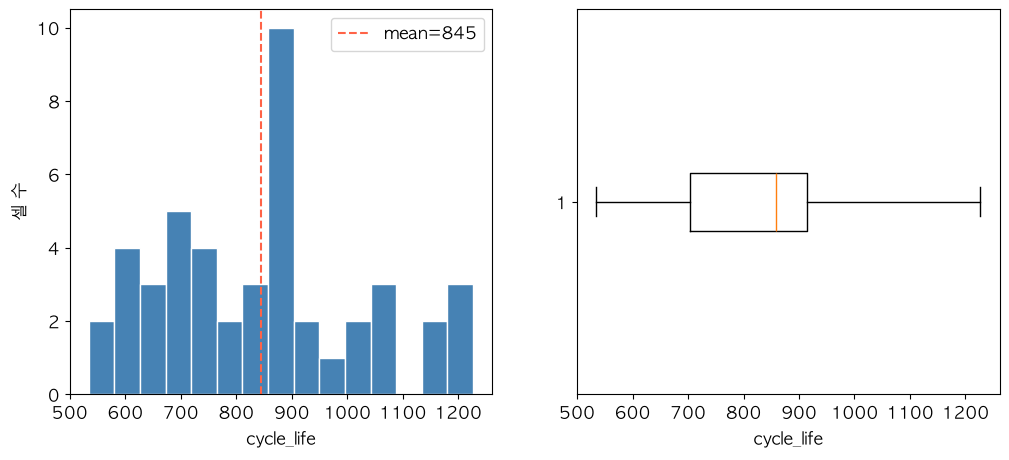

count      46.0
mean      845.0
std       185.0
min       534.0
25%       703.0
50%       858.0
75%       914.0
max      1227.0

장수명(>1000): 10개 (22%)
단수명(<500) : 0개
550 미만     : 1개  (논문 분류 기준 550)
IQR 기준 이상치: Empty DataFrame
Columns: [cell, cycle_life, policy]
Index: []


In [2]:
cl = cells.cycle_life
fig, ax = plt.subplots(1, 2)
ax[0].hist(cl, bins=15, color='steelblue', edgecolor='white')
ax[0].axvline(cl.mean(), color='tomato', ls='--', label=f'mean={cl.mean():.0f}'); ax[0].legend()
ax[0].set_xlabel('cycle_life'); ax[0].set_ylabel('셀 수')
ax[1].boxplot(cl, orientation='horizontal'); ax[1].set_xlabel('cycle_life')
plt.show()

print(cl.describe().round(0).to_string())
print(f"\n장수명(>1000): {(cl>1000).sum()}개 ({(cl>1000).mean():.0%})")
print(f"단수명(<500) : {(cl<500).sum()}개")
print(f"550 미만     : {(cl<550).sum()}개  (논문 분류 기준 550)")
print(f"IQR 기준 이상치:", cells[(cl < cl.quantile(.25)-1.5*(cl.quantile(.75)-cl.quantile(.25))) | (cl > cl.quantile(.75)+1.5*(cl.quantile(.75)-cl.quantile(.25)))].to_string())

**관찰**
- (작성)

**시사점**
- (작성: 분류 기준 550을 쓰면 클래스 비율이 어떻게 되는지 → 회귀 vs 분류 판단 근거)

## Q2. 열화 곡선 (방전 용량 QD)

공칭 용량 1.080 Ah | 제거 행 48 (0.12%)


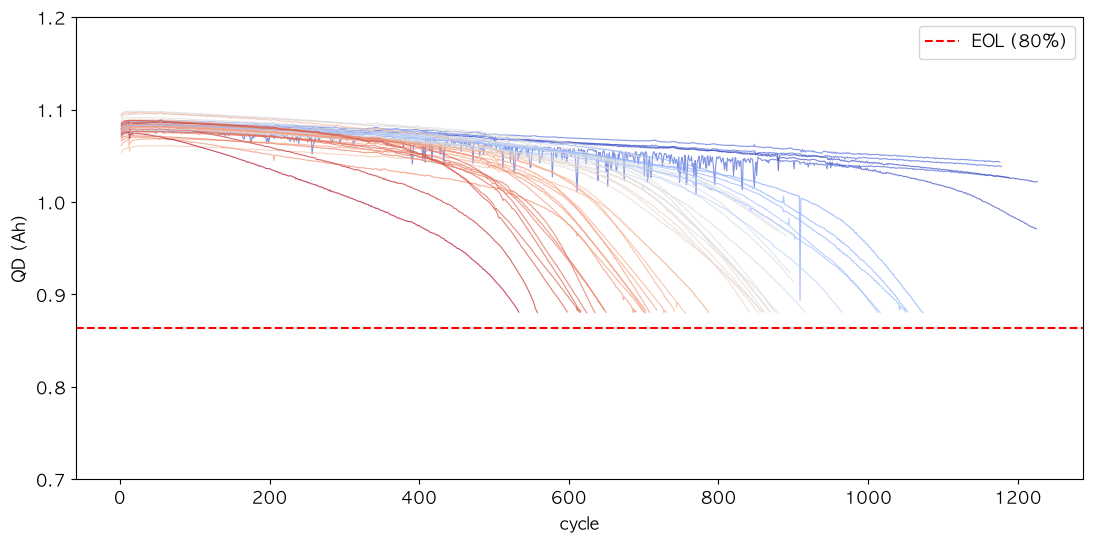

In [3]:
nom = df[df.cycle <= 5].groupby('cell').QDischarge.median().median()
clean = df[df.QDischarge.between(nom*0.8, nom*1.2)]      # 초기 스파이크 제거
print(f'공칭 용량 {nom:.3f} Ah | 제거 행 {len(df)-len(clean)} ({(len(df)-len(clean))/len(df):.2%})')

fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.cm.coolwarm_r; lo, hi = cells.cycle_life.min(), cells.cycle_life.max()
for c, g in clean.groupby('cell'):
    ax.plot(g.cycle, g.QDischarge, color=cmap((g.cycle_life.iloc[0]-lo)/(hi-lo)), lw=.8, alpha=.7)
ax.axhline(nom*0.8, color='red', ls='--', label='EOL (80%)')
ax.set_ylim(0.7, 1.2); ax.set_xlabel('cycle'); ax.set_ylabel('QD (Ah)'); ax.legend(); plt.show()

In [ ]:
# 열화 가속 여부: 수명 대비 구간별 용량 감소율, knee 후보 = 기울기가 처음으로 2배 이상 가팔라지는 지점
def knee(g, w=50):
    q = g.QDischarge.rolling(w, center=True, min_periods=w//2).mean().values
    s = -np.gradient(q)                                   # 사이클당 용량 감소
    base = np.median(s[w:200]) if len(s) > 200 else np.nan
    idx = np.where((np.arange(len(s)) > 200) & (s > 2*base))[0]
    return idx[0]+1 if len(idx) else np.nan

kn = clean.groupby('cell').apply(knee).rename('knee')
k = cells.merge(kn, left_on='cell', right_index=True)
k['knee_ratio'] = k.knee / k.cycle_life
print(f"knee 탐지 셀: {k.knee.notna().sum()}/{len(k)}  | knee/수명 중앙값: {k.knee_ratio.median():.2f}")
plt.scatter(k.knee, k.cycle_life); plt.xlabel('knee 후보 사이클'); plt.ylabel('cycle_life'); plt.show()

**관찰**
- (작성: 초기 용량이 균일한가? 열화가 선형인가 가속되는가? knee가 있는가?)

**시사점**
- (작성: 초기 QD만으로는 구분이 안 보임 → ΔQ(V) 필요 등)

## Q3. ΔQ(V) 곡선 (사이클 100 − 사이클 10)

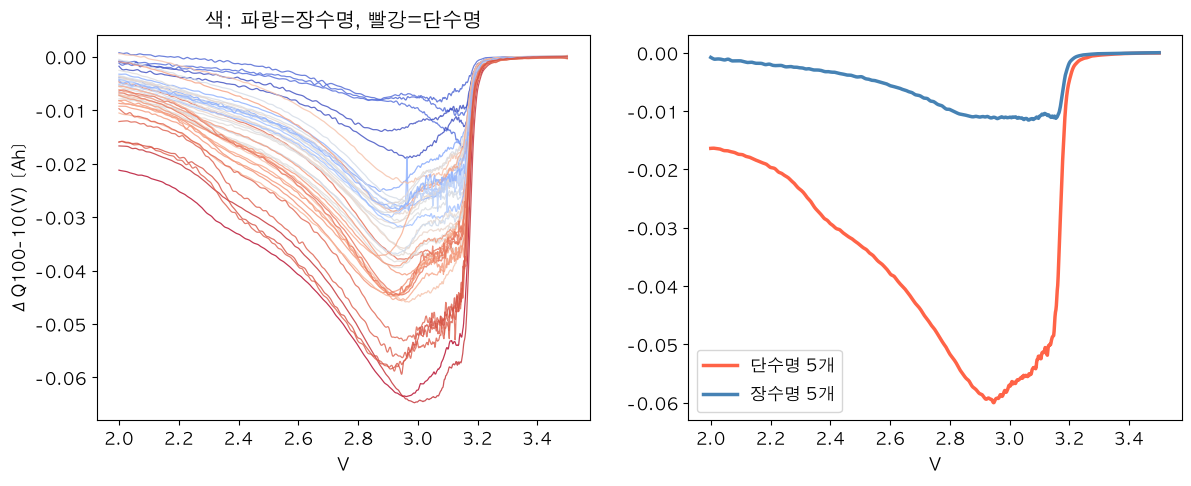

In [4]:
dq = z['q100'] - z['q10']                      # (46, 1000)
life = cells.cycle_life.values
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i in range(len(dq)):
    ax[0].plot(V, dq[i], color=cmap((life[i]-lo)/(hi-lo)), lw=.9, alpha=.8)
ax[0].set_xlabel('V'); ax[0].set_ylabel('ΔQ100-10(V) [Ah]'); ax[0].set_title('색: 파랑=장수명, 빨강=단수명')

order = np.argsort(life)
for name, idx, col in [('단수명 5개', order[:5], 'tomato'), ('장수명 5개', order[-5:], 'steelblue')]:
    ax[1].plot(V, dq[idx].mean(0), color=col, lw=2.5, label=name)
ax[1].set_xlabel('V'); ax[1].legend(); plt.show()

In [ ]:
# 곡선 → 숫자 하나로: 논문의 핵심 feature = log10(|분산|), log10(|최솟값|)
feat = pd.DataFrame({'cell': cells.cell, 'cycle_life': life,
                     'dQ_log_var': np.log10(np.abs(np.nanvar(dq, axis=1))),
                     'dQ_log_min': np.log10(np.abs(np.nanmin(dq, axis=1)))})
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, c in zip(ax, ['dQ_log_var', 'dQ_log_min']):
    a.scatter(feat[c], feat.cycle_life, edgecolors='white'); a.set_xlabel(c); a.set_ylabel('cycle_life')
    a.set_title(f"Pearson r = {feat[c].corr(feat.cycle_life):.3f}  |  Spearman = {feat[c].corr(feat.cycle_life, method='spearman'):.3f}")
plt.show()

**관찰**
- (작성: 장/단수명 곡선 모양 차이, 두 통계값의 상관)

**시사점**
- (작성: feature 후보로 채택 여부)

## Q4. 충전 조건(C-rate)과 수명

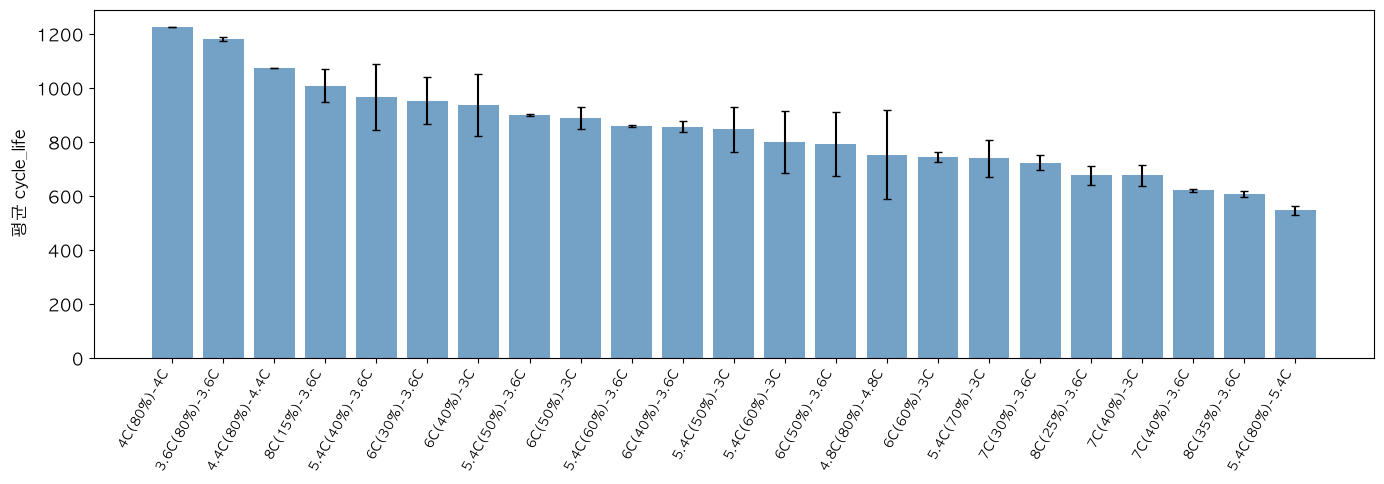

,mean,std,count
policy,,,
4C(80%)-4C,1226.5,0.707107,2
3.6C(80%)-3.6C,1182.0,7.000000,3
4.4C(80%)-4.4C,1074.0,NaN,1
8C(15%)-3.6C,1008.5,60.104076,2
5.4C(40%)-3.6C,966.5,123.743687,2
6C(30%)-3.6C,952.5,86.974134,2
6C(40%)-3C,935.5,115.258405,2
5.4C(50%)-3.6C,899.5,3.535534,2
6C(50%)-3C,888.5,40.305087,2


In [5]:
pl = cells.groupby('policy').cycle_life.agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(pl)), pl['mean'], yerr=pl['std'].fillna(0), color='steelblue', alpha=.75, capsize=3)
ax.set_xticks(range(len(pl))); ax.set_xticklabels(pl.index, rotation=60, ha='right', fontsize=9)
ax.set_ylabel('평균 cycle_life'); plt.tight_layout(); plt.show()
pl

c1           -0.580
soc           0.235
c2           -0.096
c_avg        -0.868
cycle_life    1.000


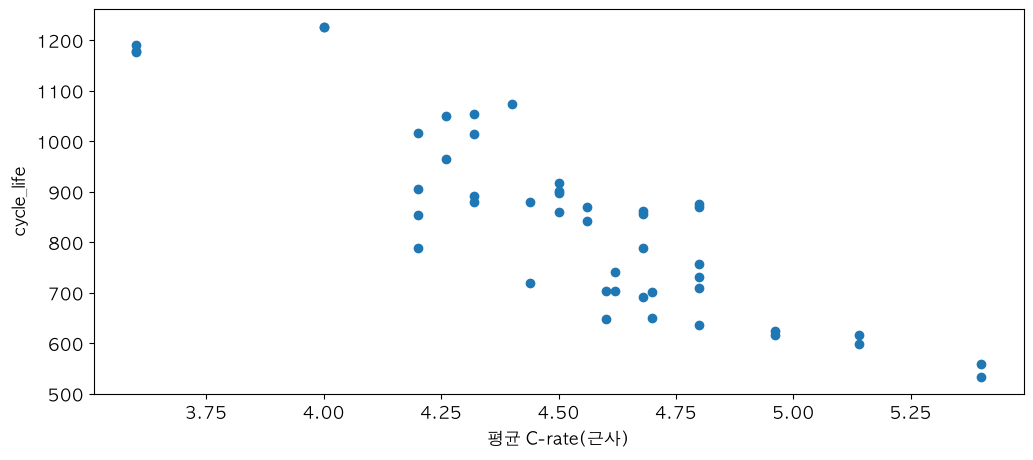

In [6]:
# 정책 문자열 → 숫자: 1단계 C-rate, 전환 SOC(%), 2단계 C-rate, 평균 C-rate(≈ 충전속도)
import re
def parse(p):
    a, soc, b = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', p).groups()
    a, soc, b = float(a), float(soc), float(b)
    return pd.Series({'c1': a, 'soc': soc, 'c2': b, 'c_avg': a*soc/100 + b*(1-soc/100)})
cells = cells.join(cells.policy.apply(parse))
print(cells[['c1', 'soc', 'c2', 'c_avg', 'cycle_life']].corr()['cycle_life'].round(3).to_string())
plt.scatter(cells.c_avg, cells.cycle_life); plt.xlabel('평균 C-rate(근사)'); plt.ylabel('cycle_life'); plt.show()

**관찰**
- (작성: 고속충전이 정말 짧은 수명인가? 같은 정책 내 편차는?)

**시사점**
- (작성: 정책 정보만으로 충분한가, 셀 신호가 추가로 필요한가)

## Q5. 초기 사이클 feature와 수명의 상관 (초기 100 사이클)

In [ ]:
e = df[df.cycle <= 100].groupby('cell')
X = pd.DataFrame({
    'QD_mean': e.QDischarge.mean(), 'QD_std': e.QDischarge.std(),
    'IR_mean': e.IR.mean(), 'Tavg_mean': e.Tavg.mean(), 'Tmax_mean': e.Tmax.mean(),
    'chargetime_mean': e.chargetime.mean()})
X['QD_slope'] = e.apply(lambda g: np.polyfit(g.cycle, g.QDischarge, 1)[0])   # 초기 용량 감소 기울기
X = X.join(feat.set_index('cell')[['dQ_log_var', 'dQ_log_min']]).join(cells.set_index('cell')[['c_avg']])
X['cycle_life'] = cells.set_index('cell').cycle_life
r = X.corr()
print(r.cycle_life.drop('cycle_life').sort_values(key=abs, ascending=False).round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7)); im = ax.imshow(r, cmap='RdBu_r', vmin=-1, vmax=1); plt.colorbar(im)
ax.set_xticks(range(len(r))); ax.set_xticklabels(r.columns, rotation=60, ha='right'); ax.set_yticks(range(len(r))); ax.set_yticklabels(r.columns)
for i in range(len(r)):
    for j in range(len(r)): ax.text(j, i, f'{r.iloc[i,j]:.1f}', ha='center', va='center', fontsize=8)
plt.show()

In [ ]:
# 다중공선성: |r| > 0.9 인 feature 쌍
f = r.drop(index='cycle_life', columns='cycle_life'); pairs = [(a, b, round(f.loc[a, b], 2)) for i, a in enumerate(f.index) for b in f.columns[i+1:] if abs(f.loc[a, b]) > .9]
pairs

**관찰**
- (작성: 수명과 가장 강한 feature, 서로 겹치는 feature)

**시사점**
- (작성: 어떤 feature를 쓰고 어떤 건 뺄지 → 선형+규제 모델 vs 트리 모델 근거)

## 종합 → 모델 전략 메모
| EDA 발견 | 시사점 | 모델링 전략 |
|---|---|---|
| | | |